In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs # Enables geographic mapping, e.g., drawing coastlines, etc
from sklearn.model_selection import cross_val_score, train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
import seaborn as sns

proj = ccrs.PlateCarree()

# Biome Multiclassifier Model

The data for different biomes on different regions is given by the file 'biomedata.csv'. In the selection of training data, we aim to choose regions such that they contain enough number of samples for each biome on the training data. This is, as it is in reality, hard to accomplish especially of data is sparse.

In [5]:
#Run this cell to load data and other variables needed for plotting!

def format_rbg_string(rgbstring):
    """Transform a RGB string to a tuple of floats that matplotlib can understand"""
    rgbs = rgbstring.split(' ')
    rgbtup = tuple(float(rgb) for rgb in rgbs)
    return rgbtup

with open('BiomeData/legend of biomes.txt', 'r') as f:
    lines = [ l.strip() for l in f.readlines()] # Remove endline characters and spaces
    
biome_names = lines[slice(0, len(lines), 2)] # Only use the biome names, not the colors
biome_names = [ ' '.join(l.split(' ')[1:]) for l in biome_names ] # Remove number in front of names
biome_rgbs = lines[slice(1, len(lines), 2)] # Filter out biome RGB colors
biome_rgbs = [format_rbg_string(rgbstr) for rgbstr in biome_rgbs]

countries = pd.read_csv('BiomeData/countries.csv')
df = pd.read_csv('BiomeData/biomedata.csv')
df.head()

,Lon,Lat,NPP,SoilR,MaxBiomeCmax,MaxBiomeLAI,VegC,LitterC,SoilC,Biome_Cmax,...,tswrf_WinterStd,clay,silt,sand,orgC,CN,pH,cellfraction,GFED-region,Pan_2007
0,39.75,-1.25,0.429,0.390,0.449,1.9821,1.225,0.758,5.941,8,...,13.821,0.19,0.16,0.65,0.007,12.0,6.2,0.663,9,Africa
1,150.25,-34.25,0.554,0.451,6.883,3.3174,6.953,3.221,10.566,7,...,26.364,0.17,0.22,0.61,0.005,12.0,6.2,0.405,14,Australia
2,24.25,27.75,0.000,0.000,0.000,0.0000,0.000,0.000,0.000,13,...,32.617,0.18,0.28,0.54,0.004,14.0,8.1,0.487,7,Africa
3,-70.25,1.25,1.146,1.162,17.930,5.0376,19.177,7.367,9.876,8,...,11.178,0.35,0.11,0.54,0.010,13.0,4.5,0.446,4,Americas
4,166.25,60.25,0.445,0.344,3.148,2.0442,4.059,3.798,29.138,1,...,21.015,0.20,0.48,0.32,0.031,17.0,6.3,0.375,10,Russia


## Region Selection and Data Visualization

In this project, we choose to train the model on specific regions. The dataset contains 14 regions as shown on the table below. 

| Region | Location              | Region | Location               | Region | Location                             |
| -----: | --------------------- | -----: | ---------------------- | -----: | ------------------------------------ |
|      1 | Canada                |      6 | North & Western Europe |     11 | China / Europe / South Korea / Japan |
|      2 | USA                   |      7 | North Africa           |     12 | South Asia (Philippines & Thailand)  |
|      3 | North South America   |      8 | Central Africa         |     13 | South East Asia (Below Philippines)  |
|      4 | Central South America |      9 | South Africa           |     14 | Australia / New Zealand              |
|      5 | South South America   |     10 | Russia                 |        |                                      |

Visualizing the regions and their predicted biomes: Below we see the dominant biomes much clearly and which regions they correspond to.

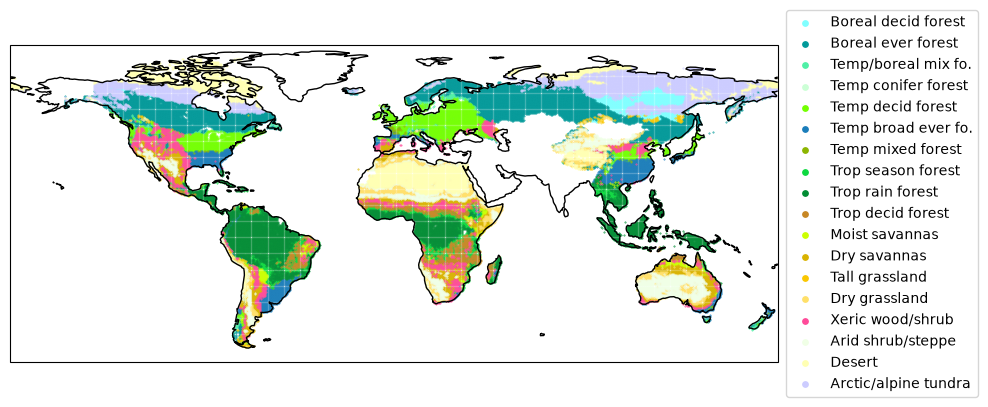

In [31]:
biome_data = df[['Lon', 'Lat', 'Biome_obs']] # We extract the location of biome ('lon,'lat') and its observed biome category 'Biome_obs'
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=proj))

# Hacky way of creating a map, pretent it is a scatterplot with lons and lats on x and y!
for i, name in enumerate(biome_names):
    biome = biome_data[biome_data['Biome_obs'] == i +1]
    biome.plot(x='Lon', y='Lat', color=biome_rgbs[i], ax=ax, kind='scatter', s=.6, label=name, marker='.')

ax.legend(markerscale=10, loc='center right', bbox_to_anchor=(1.27, .5)) # Make markers bigger
ax.coastlines()
plt.tight_layout()
plt.show()

To have a better understanding of how the biomes are distributed, we create a crosstab matrix. This allows us to visualize the number of unique biomes on each region. We then select appropriate region(s) that contain most biomes. 

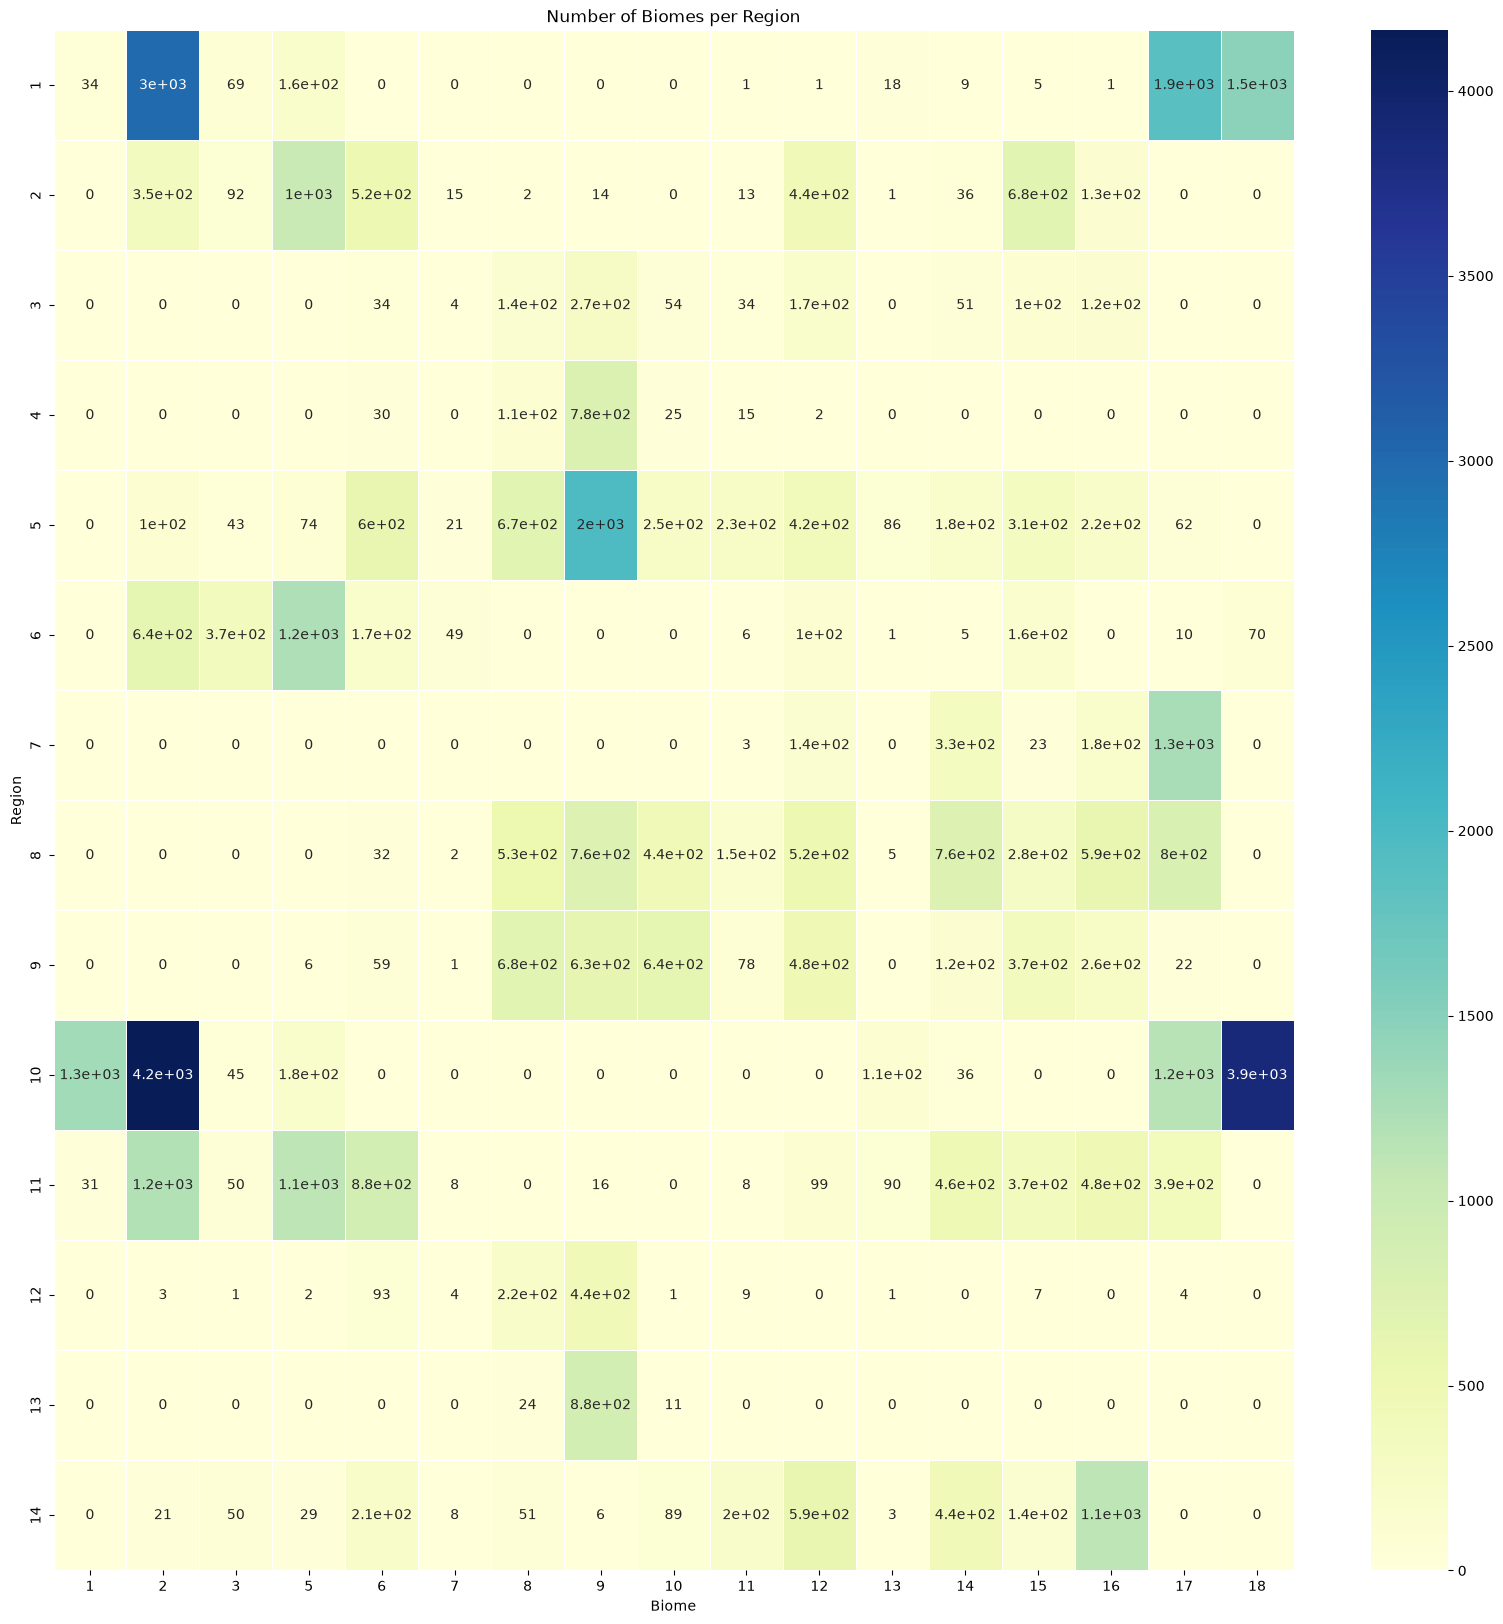

In [9]:
# Crosstab counts how many times each biome appears in each region
matrix = pd.crosstab(df['GFED-region'], df['Biome_obs'])

plt.figure(figsize=(20,20))
sns.heatmap(matrix, annot=True, cmap="YlGnBu", linewidths=0.5)
plt.title("Number of Biomes per Region")
plt.ylabel("Region")
plt.xlabel("Biome")
plt.savefig("biomeregion.jpg", dpi=300, bbox_inches='tight')
plt.show()

In [43]:
# We chose the regions: 5, 6 and 10.
regional_df = df[(df['GFED-region'] == 10)|(df['GFED-region'] == 5)|(df['GFED-region'] == 6)]
regional_df = regional_df.drop(['GFED-region','Pan_2007'], axis=1)


Note that the selected regions are heavily concentrated on some regions. Therefore, we expect the model to predict better here! To see this, we plot a histogram below.

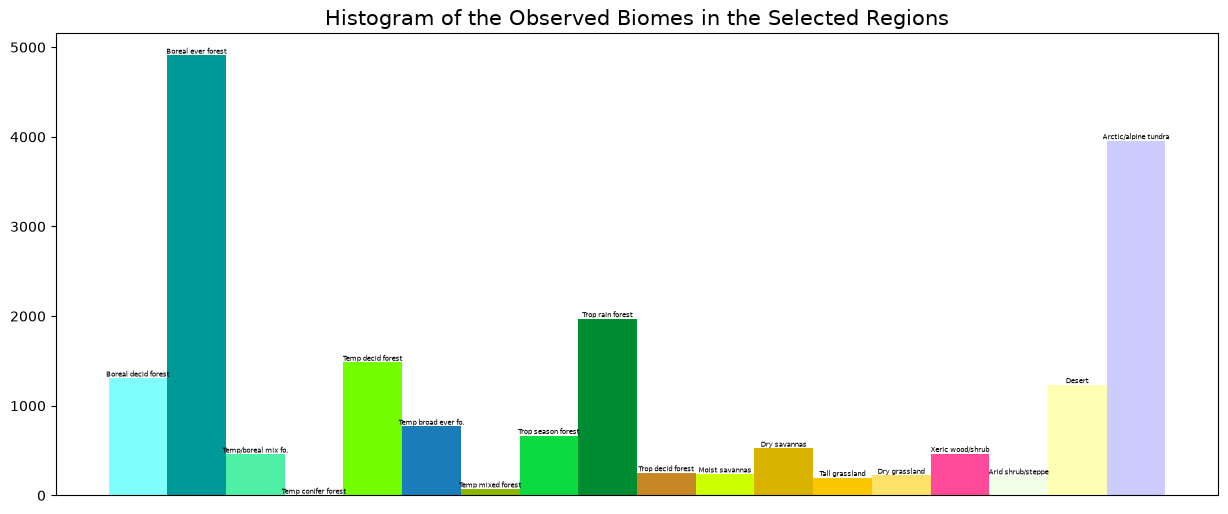

In [44]:
plt.figure(figsize=(15, 6))
counts, bins, patches = plt.hist(regional_df['Biome_obs'], bins=18)

for patch, color in zip(patches, biome_rgbs):
    patch.set_facecolor(color)

# Add text labels
for i in range(len(counts)):
    # Position: middle of the bin on x-axis, counts[i] on y-axis
    x = (bins[i] + bins[i+1]) / 2
    y = counts[i]
    plt.text(x, y, biome_names[i], ha='center', va='bottom', fontsize = 5)

plt.xticks([])
plt.title('Histogram of the Observed Biomes in the Selected Regions', fontsize = 15)
plt.savefig("regionHistogram.jpg", dpi=300, bbox_inches='tight')
plt.show()

# Random Forest classification model

The data is first shuffled and the target variable `Biome_obs` is separated from the input features. The data is then split into **training (80%)**, **test (20%)**, and the training data is further split into **training (80%)** and **validation (20%)** sets.

A **Random Forest Classifier** is then created using multiple decision trees (`n_estimators`). Each tree learns patterns from the training data, and the forest combines their predictions to classify the biome.

The model is finally trained using `X_train` and `y_train`:

```python
biome_class.fit(X_train, y_train)

In [48]:
regional_df_copy = regional_df.copy()

"We exclude the predictions made by previous models in the training data"
regional_df_copy = regional_df_copy.drop(['Biome_Cmax', 'Biome_LAI'], axis=1) 
regional_df_copy = regional_df_copy.sample(frac=1) # we shuffle the data

y = regional_df_copy.pop('Biome_obs') # Get the target feature

In [49]:
X_train, X_test, y_train, y_test = train_test_split(regional_df_copy, y, random_state=42, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, random_state=42, test_size=0.2)

biome_class = RandomForestClassifier(n_estimators=179, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=1, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False)
biome_class.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",179
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

# Checking Forest Performance
The trained `biome_class` model is used to predict the biome classes in the unseen test data `X_test`. The predictions (`y_pred`) are then compared with the actual biome classes (`y_test`) using **accuracy**, which measures the proportion of correct predictions.

The printed value shows the model's **accuracy on the test data**.

In [52]:
y_pred = biome_class.predict(X_test)

score_rfc_test = accuracy_score(y_test, y_pred)
print(f'Accuracy of RandomForestClassifier on test data: {score_rfc_test*100:.2f}%')

Accuracy of RandomForestClassifier on test data: 94.83%


A **5-fold cross-validation** is also performed on ALL of the regions. The data is divided into five parts, and the model is trained and evaluated five times using different parts as the validation data. The mean accuracy shows the average performance, while the standard deviation indicates how much the accuracy varies between the folds.

Finally, the **classification report** provides more detailed performance measures for each biome class, including **precision, recall, F1-score, and the number of observations (support)**.

In [54]:
X = df.copy().drop(['GFED-region','Pan_2007','Biome_Cmax','Biome_LAI'], axis=1)
Y = X.pop('Biome_obs')
y_pred = biome_class.predict(X)

score_rfc_test = accuracy_score(Y, y_pred)
print(f'Accuracy of RandomForestClassifier on all data: {score_rfc_test*100:.2f}%')

folds = KFold(n_splits=5, shuffle=True, random_state=27)
#folds = KFold(n_splits=10, shuffle=True, random_state=27)

score_cv_test = cross_val_score(biome_class, X, Y, cv=folds)

print("Average accuracy on cross validation of all data: %0.4f ( %0.2f)" % (score_cv_test.mean(), score_cv_test.std()))

print("\nClassification Report:")
print(classification_report(Y, y_pred))

Accuracy of RandomForestClassifier on all data: 83.97%
Average accuracy on cross validation of all data: 0.9430 ( 0.00)

Classification Report:
              precision    recall  f1-score   support

           1       0.94      0.97      0.96      1372
           2       0.96      0.97      0.97      9484
           3       0.73      0.72      0.72       720
           5       0.80      0.97      0.87      3800
           6       0.95      0.75      0.84      2626
           7       0.94      0.45      0.61       112
           8       0.71      0.89      0.79      2415
           9       0.95      0.98      0.97      5773
          10       0.88      0.45      0.59      1518
          11       0.34      0.78      0.48       753
          12       0.61      0.62      0.61      2978
          13       0.91      0.88      0.89       315
          14       0.63      0.37      0.47      2429
          15       0.63      0.56      0.60      2447
          16       0.55      0.59      0.57  

### Confusion Matrix

A **confusion matrix** shows how well the classification model predicts each biome class by comparing the **actual classes** (`y_test`) with the **predicted classes** from `biome_class`.

- **Diagonal values** = correctly classified observations.
- **Off-diagonal values** = observations that were incorrectly classified as another biome.

This makes it possible to see not only the overall accuracy, but also **which biome classes are being confused with each other**.

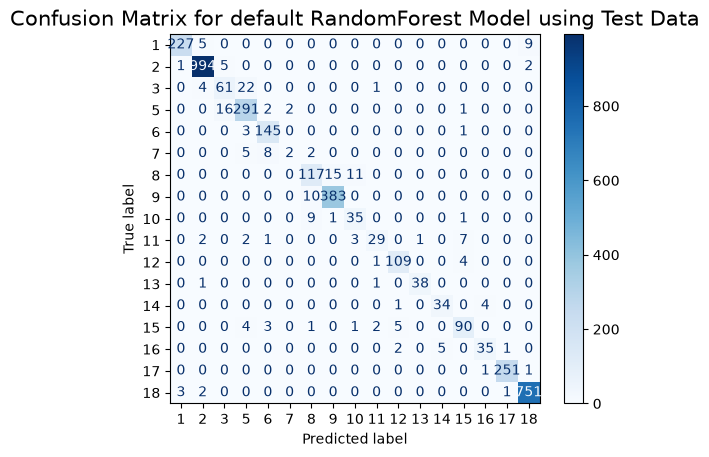

In [55]:
ConfusionMatrixDisplay.from_estimator(biome_class, X_test, y_test , cmap='Blues')
plt.title("Confusion Matrix for default RandomForest Model using Test Data", fontsize=15)
plt.show()

### Hyperparameter tuning with Grid Search

This code uses **GridSearchCV** to find the best value for the number of trees (`n_estimators`) in the Random Forest model. Several possible values between **175 and 179 trees** are tested using **5-fold cross-validation**.

For each value, the model is trained and its **accuracy** is evaluated. The combination that gives the highest cross-validation accuracy is selected as the best model.

The final lines retrieve and print the selected model's parameters, including:
- `max_depth` – maximum depth of each decision tree.
- `n_estimators` – number of trees in the Random Forest.
- `min_samples_split` – minimum number of samples required to split a node.
- `min_samples_leaf` – minimum number of samples required in a leaf.
- `best_score_` – the highest average cross-validation accuracy found by the grid search.

In this case, only `n_estimators` is actually varied by `GridSearchCV`; the other parameters are simply reported from the best estimator.

In [56]:
n_depths_range = np.arange(1, 10, 2, dtype=np.int16)
n_estimators_range = np.arange(175, 180, dtype=np.int16) # CV number of trees (estimators) 10, 20, ..., 100
n_samples_range =np.arange(2, 5)
n_samples_leaf = np.arange(1,5)

folds = KFold(n_splits=5, shuffle=True, random_state=27)

#We optimize based on one variable to save time
params = {'n_estimators': n_estimators_range,
         }
"""
params = {'n_estimators': n_estimators_range,
          'n_depths': n_depths_range,
          'n_samples': n_samples_range,
          'n_samples_leaf': n_samples_leaf,
         }
"""

rfc_gscv = GridSearchCV(biome_class, param_grid = params, scoring = "accuracy",cv = folds)
# Fit the model
model_rfc = rfc_gscv.fit(X_val, y_val)

# Model best estimator
max_depths=model_rfc.best_estimator_.get_params()["max_depth"]
max_trees= model_rfc.best_estimator_.get_params()["n_estimators"]
min_split= model_rfc.best_estimator_.get_params()["min_samples_split"]
min_leaf= model_rfc.best_estimator_.get_params()["min_samples_leaf"]

max_cvs= rfc_gscv.best_score_
print("Max Depth: ", max_depths)
print("Max Trees: ",max_trees)
print("Min Split: ", min_split)
print("Min Leaf: ", min_leaf)
print("Max CV: ",max_cvs)

Max Depth:  None
Max Trees:  175
Min Split:  2
Min Leaf:  1
Max CV:  0.9273927392739274


In [57]:
best_class = model_rfc.best_estimator_ # Get the best model

In [58]:
y_pred = best_class.predict(X_test)

score_rfc_test = accuracy_score(y_test, y_pred)
print(f'Accuracy of RandomForestClassifier on all data: {score_rfc_test*100:.2f}%')

folds = KFold(n_splits=5, shuffle=True, random_state=27)

score_cv_train = cross_val_score(biome_class, X_train, y_train, cv=folds)
score_cv_test = cross_val_score(biome_class, X_test, y_test, cv=folds)

print("Average accuracy on cross validation of train data: %0.4f ( %0.2f)" % (score_cv_train.mean(), score_cv_train.std()))
print("Average accuracy on cross validation of test data: %0.4f ( %0.2f)" % (score_cv_test.mean(), score_cv_test.std()))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy of RandomForestClassifier on all data: 92.56%
Average accuracy on cross validation of train data: 0.9492 ( 0.00)
Average accuracy on cross validation of test data: 0.9290 ( 0.00)

Classification Report:
              precision    recall  f1-score   support

           1       0.96      0.93      0.95       241
           2       0.96      0.99      0.98      1002
           3       0.71      0.56      0.62        88
           5       0.89      0.91      0.90       312
           6       0.89      0.95      0.92       149
           7       0.30      0.18      0.22        17
           8       0.80      0.77      0.79       143
           9       0.94      0.96      0.95       393
          10       0.77      0.65      0.71        46
          11       0.80      0.71      0.75        45
          12       0.81      0.87      0.84       114
          13       0.87      0.82      0.85        40
          14       0.88      0.54      0.67        39
          15       0.77      0.

### Feature importance and correlation matrix

First, the model's **feature importance** values are extracted from the Random Forest. The features are then ordered from most to least important.

A **correlation matrix** is calculated for the features in this order. The heatmap shows the **absolute correlation** between each pair of variables, where values closer to 1 indicate a stronger linear relationship between the variables.

The resulting heatmap therefore helps identify **groups of features that are strongly correlated with each other**, which can indicate that they contain similar information.

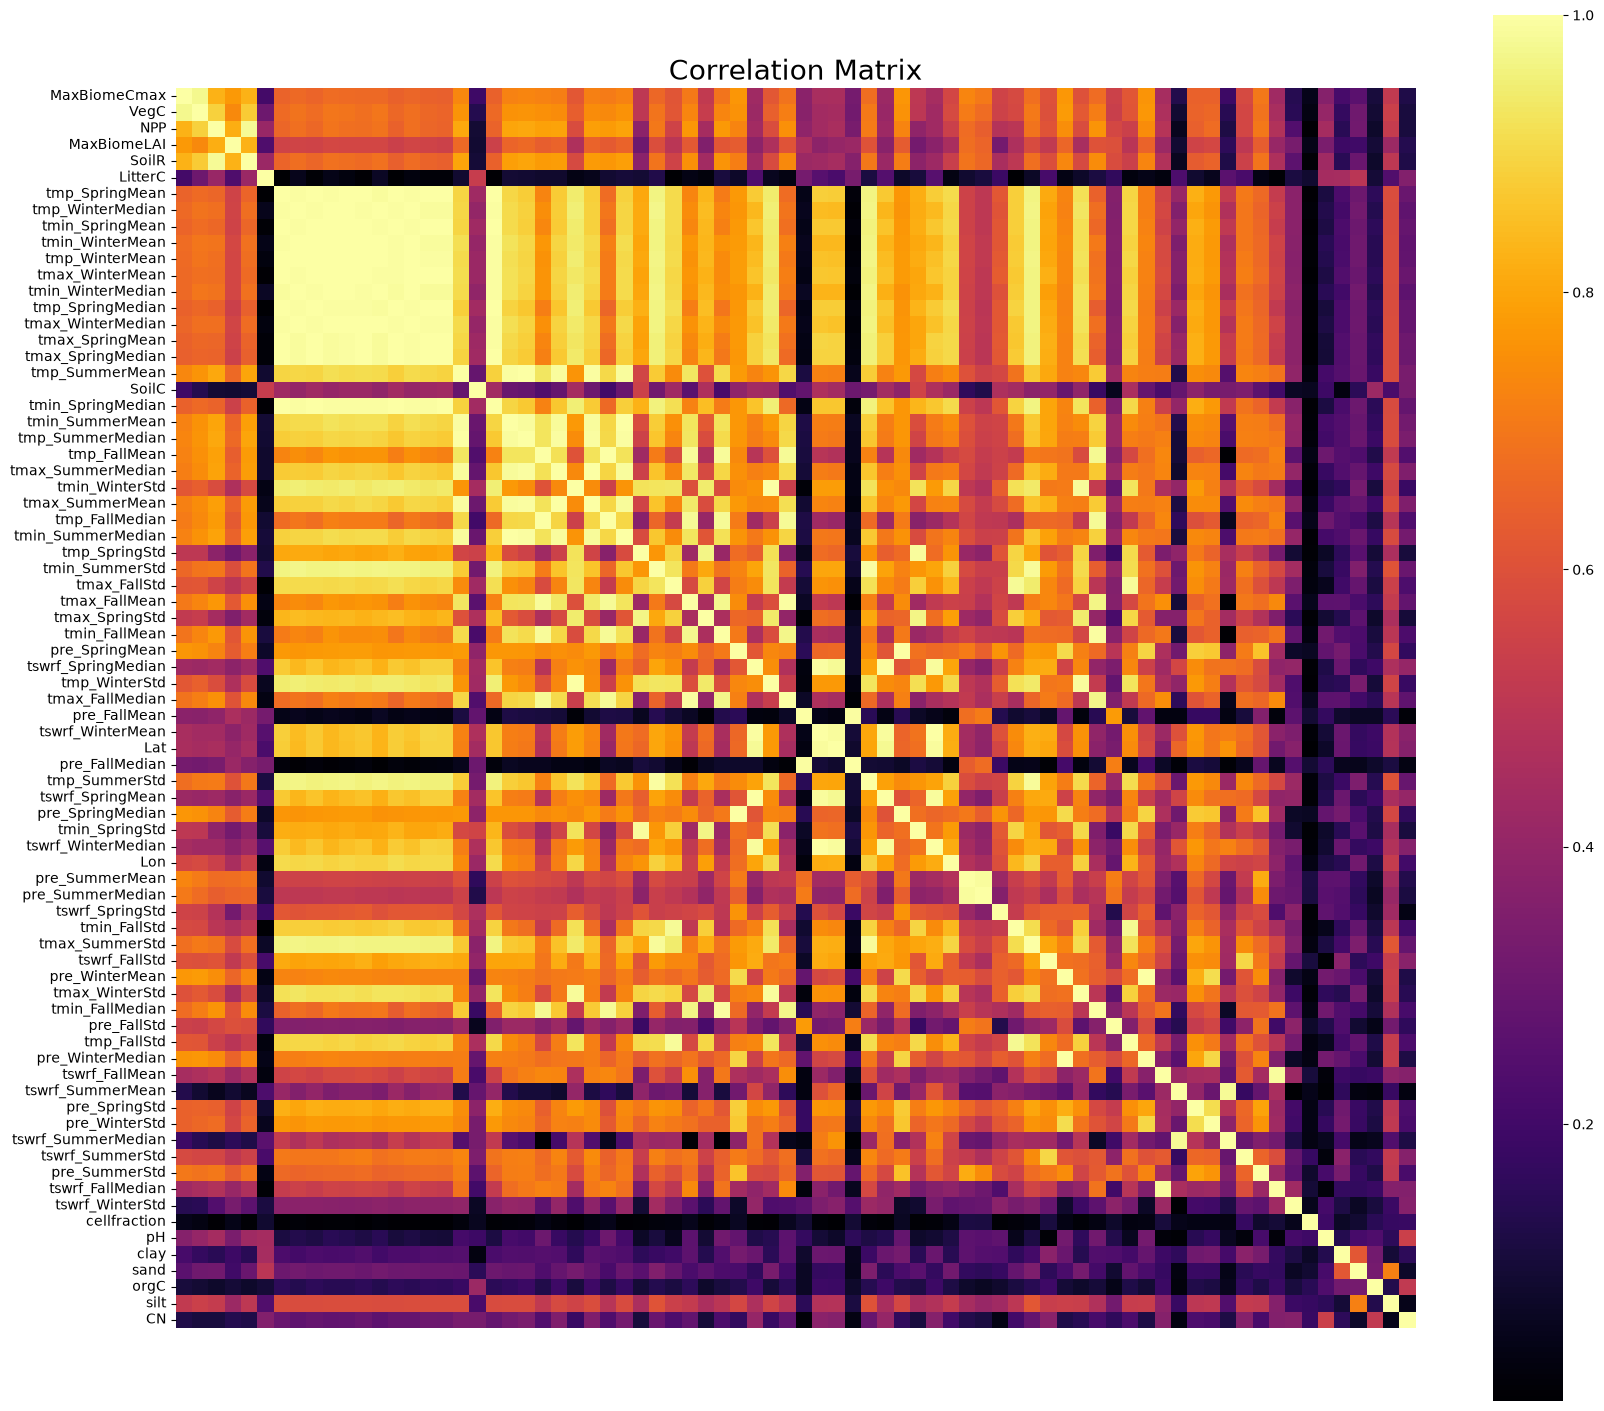

In [59]:
importances = biome_class.feature_importances_
feat_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

reorder = feat_importance_df['feature'].astype(str).tolist()

# Compute correlation
corr = copy2_regional_df[reorder].corr()

# Plot heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(abs(corr), annot=False, cmap='inferno', fmt='.2f', square=True)
# Rotate x-axis labels
plt.xticks([])
# Rotate y-axis labels (optional)
plt.yticks(rotation=0)
plt.title('Correlation Matrix', fontsize=20)
plt.savefig('correlationMatrixsmaller.jpg', dpi=300, bbox_inches='tight')
plt.show()

Here, the **55 least important features** identified from the previous feature-importance analysis are removed. The Random Forest is then retrained using the remaining features.

The purpose is to test whether using **all available features is necessary** for accurate biome classification. By removing the least important features and comparing the performance with the original model, we can see whether a smaller set of features provides similar or different predictive performance.

The data is again divided into training, validation, and test sets, and a new `RandomForestClassifier` is trained using the reduced feature set.

If the pruned model achieves similar accuracy to the model using all features, this suggests that the removed features provide relatively little additional predictive information.

In [60]:
removeCols = feat_importance_df['feature'][-55:].astype(str).tolist()
regional_pruneddf = regional_df.copy().drop(removeCols, axis=1)
regional_pruneddf = regional_pruneddf.drop(['Biome_Cmax','Biome_LAI'], axis=1)
y = regional_pruneddf.pop('Biome_obs') # Get the target feature

X_train, X_test, y_train, y_test = train_test_split(regional_pruneddf, y, random_state=42, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, random_state=42, test_size=0.2)

biome_class = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=1, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False)
biome_class.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [61]:
y_pred = biome_class.predict(X_test)

score_rfc_test = accuracy_score(y_test, y_pred)
print(f'Accuracy of RandomForestClassifier on all data: {score_rfc_test*100:.2f}%')

folds = KFold(n_splits=5, shuffle=True, random_state=27)

score_cv_train = cross_val_score(biome_class, X_train, y_train, cv=folds)
score_cv_test = cross_val_score(biome_class, X_test, y_test, cv=folds)

print("Average accuracy on cross validation of train data: %0.4f ( %0.2f)" % (score_cv_train.mean(), score_cv_train.std()))
print("Average accuracy on cross validation of test data: %0.4f ( %0.2f)" % (score_cv_test.mean(), score_cv_test.std()))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy of RandomForestClassifier on test data: 0.9562
Average accuracy on cross validation of train data: 0.9489 ( 0.00)
Average accuracy on cross validation of test data: 0.9311 ( 0.01)

Classification Report:
              precision    recall  f1-score   support

           1       0.97      0.97      0.97       261
           2       0.98      0.99      0.98       956
           3       0.87      0.77      0.82        81
           5       0.95      0.96      0.95       305
           6       0.96      0.96      0.96       152
           7       0.64      0.60      0.62        15
           8       0.86      0.93      0.90       134
           9       0.99      0.97      0.98       404
          10       0.87      0.85      0.86        48
          11       0.86      0.80      0.83        45
          12       0.91      0.93      0.92       124
          13       0.85      0.69      0.76        42
          14       0.84      0.70      0.76        46
          15       0.86      0

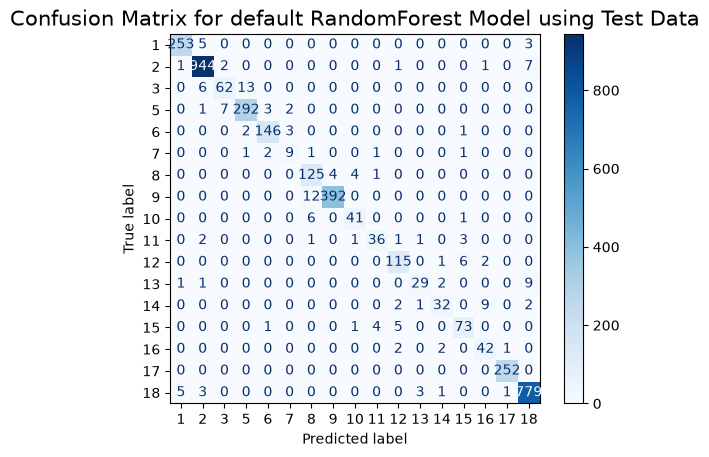

In [62]:
ConfusionMatrixDisplay.from_estimator(biome_class, X_test, y_test , cmap='Blues')
plt.title("Confusion Matrix for default RandomForest Model using Test Data", fontsize=15)
plt.show()

### Evaluation on unseen regions

The trained model is applied to regions that were **not included in the training data**. Its predictions are then compared with the observed biome classes in these new regions to evaluate how well the model **generalizes to previously unseen regions**.

This provides an indication of how well the model can perform when applied to data from regions outside those used during training.

| Region | Location               
| -----: | ---------------------  
|      1 | Canada                 
|      2 | USA                   

In [65]:
test_regional_df = df[(df['GFED-region'] == 1)|(df['GFED-region'] == 2)]
test_regional_df = test_regional_df.drop(['Pan_2007','GFED-region','Biome_Cmax', 'Biome_LAI']+removeCols, axis=1)
X_test = test_regional_df.sample(frac=1)
y_test = X_test.pop('Biome_obs')

#Here we see zero performance on biomes it has not been trained on.
score_rfc_test = accuracy_score(y_test, biome_class.predict(X_test))
print(f'Accuracy of RandomForestClassifier on all data: {score_rfc_test*100:.2f}%')

print("\nClassification Report:")
print(classification_report(y_test, biome_class.predict(X_test)))

Accuracy of RandomForestClassifier on all data: 86.29%

Classification Report:
              precision    recall  f1-score   support

           1       0.41      0.68      0.51        34
           2       0.87      0.97      0.92      3350
           3       0.36      0.30      0.33       161
           5       0.84      0.93      0.88      1173
           6       0.97      0.61      0.75       518
           7       0.50      0.13      0.21        15
           8       0.50      1.00      0.67         2
           9       1.00      0.86      0.92        14
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00        14
          12       0.89      0.39      0.54       445
          13       0.00      0.00      0.00        19
          14       0.34      0.67      0.45        45
          15       0.52      0.42      0.46       680
          16       0.72      0.62      0.67       128
          17       1.00      1.00      1.00      1885
  

C:\Users\krane\miniforge3\envs\statistics\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\krane\miniforge3\envs\statistics\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\krane\miniforge3\envs\statistics\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", re

| Region | Location               
| -----: | ---------------------  
|      8 | Central Africa                
|      9 | South Africa                   

In [66]:
test_regional_df = df[(df['GFED-region'] == 8)|(df['GFED-region'] == 9)]
test_regional_df = test_regional_df.drop(['Pan_2007','GFED-region','Biome_Cmax', 'Biome_LAI']+removeCols, axis=1)
X_test = test_regional_df.sample(frac=1)
y_test = X_test.pop('Biome_obs')

score_rfc_test = accuracy_score(y_test, biome_class.predict(X_test))
print(f'Accuracy of RandomForestClassifier on all data: {score_rfc_test*100:.2f}%')

print("\nClassification Report:")
print(classification_report(y_test, biome_class.predict(X_test)))

Accuracy of RandomForestClassifier on all data: 67.54%

Classification Report:
              precision    recall  f1-score   support

           5       1.00      0.33      0.50         6
           6       0.68      1.00      0.81        91
           7       0.00      0.00      0.00         3
           8       0.79      0.86      0.82      1206
           9       0.96      0.97      0.97      1388
          10       0.88      0.61      0.72      1087
          11       0.30      0.81      0.44       231
          12       0.44      0.70      0.54      1001
          13       0.00      0.00      0.00         5
          14       0.86      0.05      0.09       880
          15       0.72      0.64      0.68       654
          16       0.39      0.49      0.43       849
          17       1.00      0.78      0.88       827

    accuracy                           0.68      8228
   macro avg       0.62      0.56      0.53      8228
weighted avg       0.75      0.68      0.66      8228



C:\Users\krane\miniforge3\envs\statistics\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\krane\miniforge3\envs\statistics\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\krane\miniforge3\envs\statistics\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

| Region | Location               
| -----: | ---------------------  
|      14 |  Australia / New Zealand                              

In [67]:
test_regional_df = df[(df['GFED-region'] == 14)]
test_regional_df = test_regional_df.drop(['Pan_2007','GFED-region','Biome_Cmax', 'Biome_LAI']+removeCols, axis=1)
X_test = test_regional_df.sample(frac=1)
y_test = X_test.pop('Biome_obs')

score_rfc_test = accuracy_score(y_test, biome_class.predict(X_test))
print(f'Accuracy of RandomForestClassifier on all data: {score_rfc_test*100:.2f}%')

print("\nClassification Report:")
print(classification_report(y_test, biome_class.predict(X_test)))

Accuracy of RandomForestClassifier on all data: 61.90%

Classification Report:
              precision    recall  f1-score   support

           2       1.00      0.29      0.44        21
           3       0.62      0.62      0.62        50
           5       0.35      0.52      0.42        29
           6       0.89      0.96      0.93       212
           7       0.00      0.00      0.00         8
           8       0.50      0.98      0.66        51
           9       1.00      1.00      1.00         6
          10       0.88      0.17      0.28        89
          11       0.39      0.91      0.55       202
          12       0.43      0.64      0.51       593
          13       0.00      0.00      0.00         3
          14       0.97      0.06      0.12       436
          15       0.68      0.74      0.71       144
          16       0.84      0.73      0.78      1117

    accuracy                           0.62      2961
   macro avg       0.61      0.54      0.50      2961
w

C:\Users\krane\miniforge3\envs\statistics\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\krane\miniforge3\envs\statistics\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\krane\miniforge3\envs\statistics\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}